load dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sentiment_analysis_results.csv")

df.head()

,review,rating,date,bank,source,sentiment_score,sentiment_label,identified_theme
0,nays,5,2026-05-17,CBE,Google Play,0.0000,Neutral,General Feedback
1,very very good 👍 thanks commercial bank of eth...,5,2026-05-17,CBE,Google Play,0.7854,Positive,General Feedback
2,so nice,5,2026-05-17,CBE,Google Play,0.4754,Positive,General Feedback
3,fantastic,5,2026-05-17,CBE,Google Play,0.5574,Positive,General Feedback
4,very nice,5,2026-05-17,CBE,Google Play,0.4754,Positive,General Feedback


sentiment distribution by bank

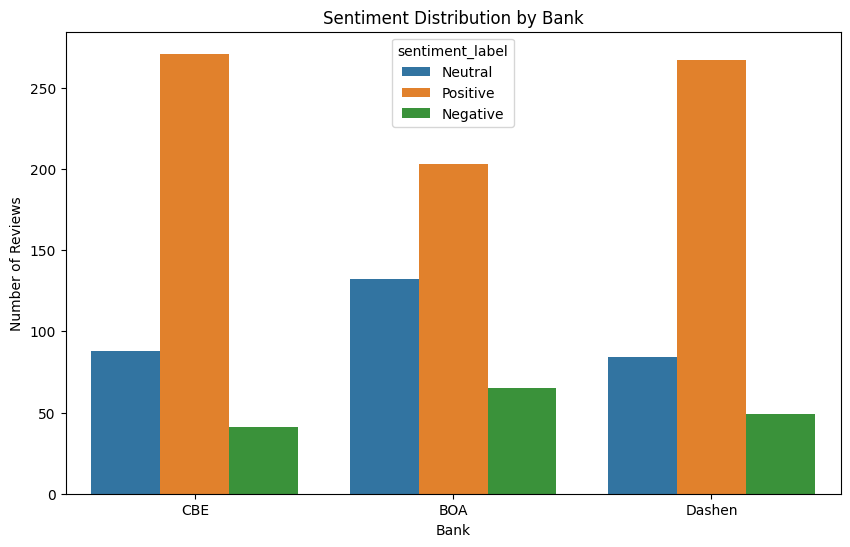

In [3]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bank",
    hue="sentiment_label"
)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.show()

rating distribution

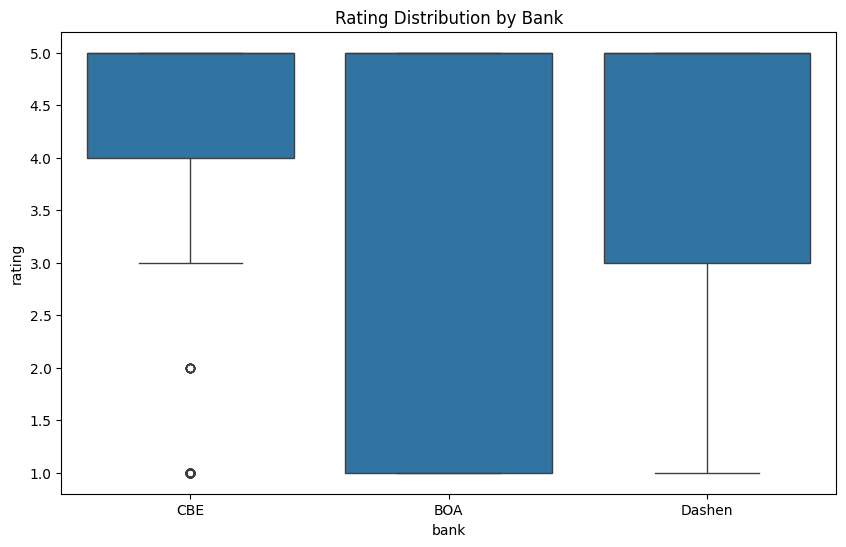

In [4]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="bank",
    y="rating"
)

plt.title("Rating Distribution by Bank")

plt.show()

theme frequency

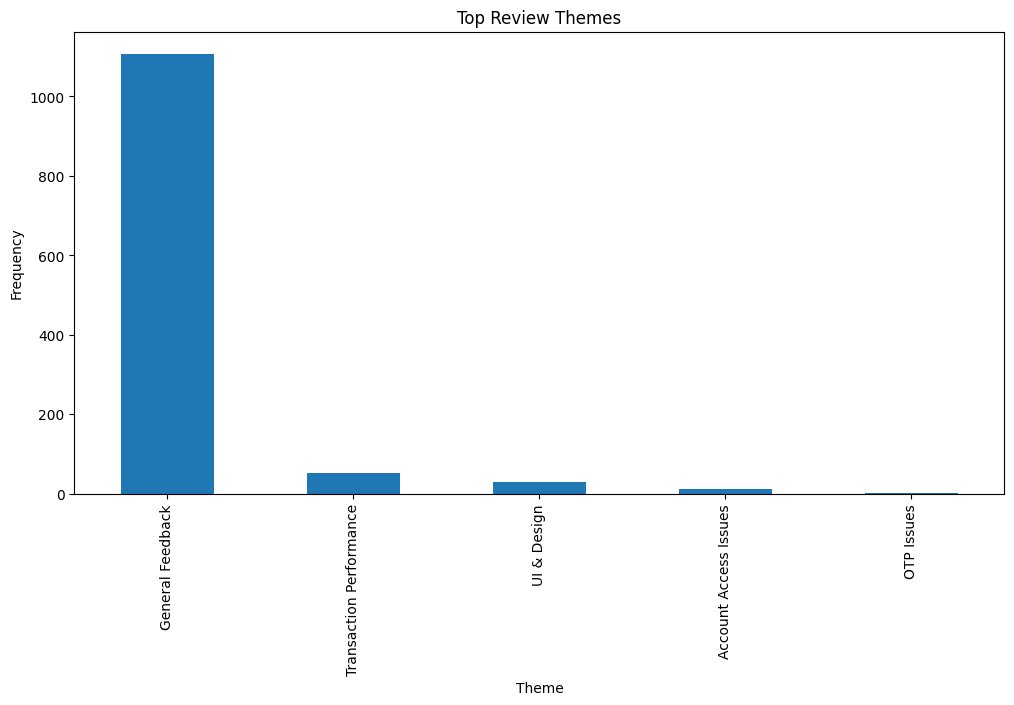

In [5]:
theme_counts = df["identified_theme"].value_counts().head(10)

plt.figure(figsize=(12, 6))

theme_counts.plot(kind="bar")

plt.title("Top Review Themes")
plt.xlabel("Theme")
plt.ylabel("Frequency")

plt.show()

sentiment trend overtime

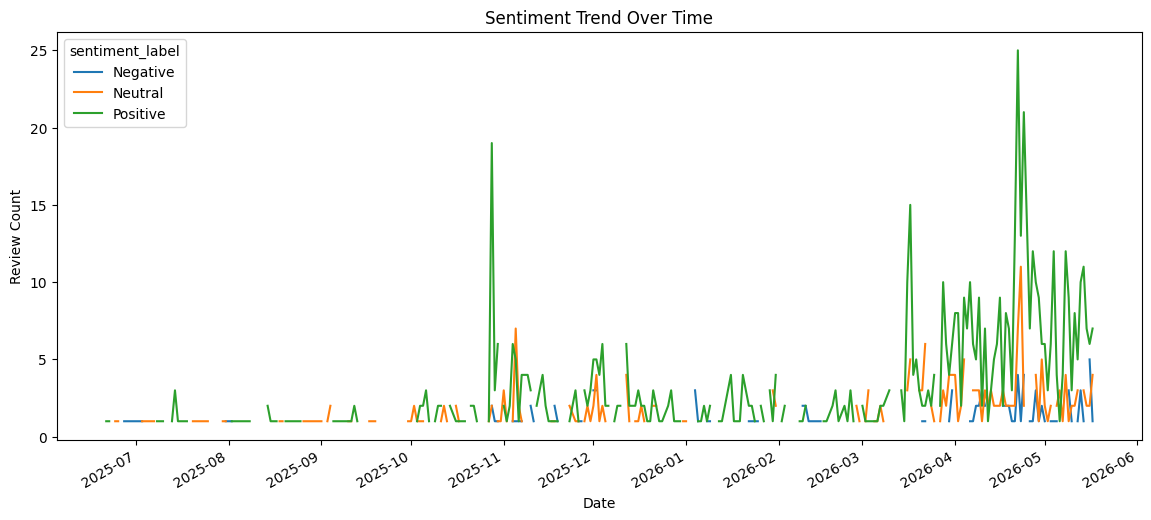

In [6]:
df["date"] = pd.to_datetime(df["date"])

trend = df.groupby([
    "date",
    "sentiment_label"
]).size().unstack()

trend.plot(figsize=(14, 6))

plt.title("Sentiment Trend Over Time")

plt.xlabel("Date")
plt.ylabel("Review Count")

plt.show()

bank comparision table

In [7]:
summary = df.groupby("bank").agg({
    "rating": "mean",
    "sentiment_score": "mean"
})

summary

,rating,sentiment_score
bank,,
BOA,3.6625,0.175047
CBE,4.1225,0.281857
Dashen,3.9950,0.302723


Commercial Bank of Ethiopia (CBE)

 Satisfaction Drivers
- Fast transfer functionality
- User-friendly interface

 Pain Points
- Slow loading during peak periods
- Login authentication issues

 Recommendations
1. Optimize backend infrastructure for peak transaction traffic.
2. Improve authentication reliability and OTP delivery systems.

 Bank of Abyssinia (BOA)

Satisfaction Drivers
- Simple navigation
- Helpful mobile features

 Pain Points
- Frequent crashes
- Slow app responsiveness

 Recommendations
1. Improve application stability and crash handling.
2. Optimize app performance for lower-end devices.

 Dashen Bank

 Satisfaction Drivers
- Smooth transaction experience
- Reliable mobile banking services

 Pain Points
- Occasional login issues
- Delayed notifications

Recommendations
1. Enhance notification systems and synchronization.
2. Strengthen session management and login consistency.